In [1]:
#Import Libs
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
#Ignore Error Messages
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [3]:
#Import Database for EDA (After Upload the Database for the Google Colab)
df = pd.read_csv('https://raw.githubusercontent.com/jrafa1607/DataScience-ML-AI/main/-%20Datasets/credit_data.csv')

In [4]:
#Database Visualization
df

,i#clientid,income,age,loan,c#default
0,1,66155.925095,59.017015,8106.532131,0
1,2,34415.153966,48.117153,6564.745018,0
2,3,57317.170063,63.108049,8020.953296,0
3,4,42709.534201,45.751972,6103.642260,0
4,5,66952.688845,18.584336,8770.099235,1
...,...,...,...,...,...
1995,1996,59221.044874,48.518179,1926.729397,0
1996,1997,69516.127573,23.162104,3503.176156,0
1997,1998,44311.449262,28.017167,5522.786693,1
1998,1999,43756.056605,63.971796,1622.722598,0


In [5]:
#Attributes View
print(df.columns)

Index(['i#clientid', 'income', 'age', 'loan', 'c#default'], dtype='object')


In [6]:
#Define New Attributes Names
df.columns = ['id', 'income', 'age', 'loan', 'result']
print(df.columns)

Index(['id', 'income', 'age', 'loan', 'result'], dtype='object')


In [7]:
#Total of Rows and Attributes
df.shape

(2000, 5)

In [8]:
#Correlation Matrix Between the Attributes
df.corr()

,id,income,age,loan,result
id,1.000000,0.039280,-0.014704,0.018931,-0.020145
income,0.039280,1.000000,-0.033687,0.441117,0.002284
age,-0.014704,-0.033687,1.000000,0.002309,-0.429759
loan,0.018931,0.441117,0.002309,1.000000,0.377160
result,-0.020145,0.002284,-0.429759,0.377160,1.000000


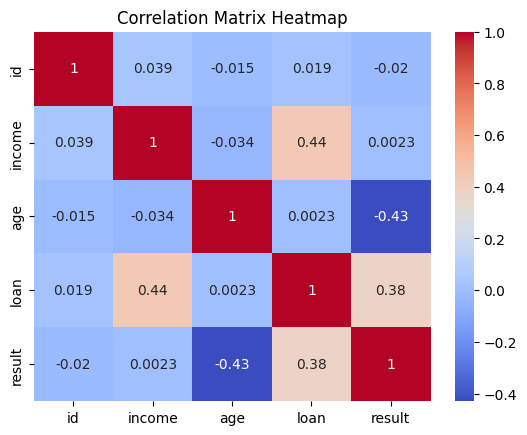

In [9]:
#Correlation Matrix Heatmap
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()

In [10]:
#Describe the DataFrame
df.describe()

,id,income,age,loan,result
count,2000.000000,2000.000000,1997.000000,2000.000000,2000.000000
mean,1000.500000,45331.600018,40.807559,4444.369695,0.141500
std,577.494589,14326.327119,13.624469,3045.410024,0.348624
min,1.000000,20014.489470,-52.423280,1.377630,0.000000
25%,500.750000,32796.459717,28.990415,1939.708847,0.000000
50%,1000.500000,45789.117313,41.317159,3974.719419,0.000000
75%,1500.250000,57791.281668,52.587040,6432.410625,0.000000
max,2000.000000,69995.685578,63.971796,13766.051239,1.000000


In [11]:
#Dataframe Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      2000 non-null   int64  
 1   income  2000 non-null   float64
 2   age     1997 non-null   float64
 3   loan    2000 non-null   float64
 4   result  2000 non-null   int64  
dtypes: float64(3), int64(2)
memory usage: 78.3 KB


In [12]:
#Check for the Null Values
print(df.isnull().sum())

id        0
income    0
age       3
loan      0
result    0
dtype: int64


In [13]:
#Show the First and the last 3 Rows
print(df.head(3), "\n")
print(df.tail(3))

   id        income        age         loan  result
0   1  66155.925095  59.017015  8106.532131       0
1   2  34415.153966  48.117153  6564.745018       0
2   3  57317.170063  63.108049  8020.953296       0 

        id        income        age         loan  result
1997  1998  44311.449262  28.017167  5522.786693       1
1998  1999  43756.056605  63.971796  1622.722598       0
1999  2000  69436.579552  56.152617  7378.833599       0


In [14]:
#Example of Search Values // Make Filters ( age <= 20 )
print(df[df['age'] <= 20])
print(df[df['age'] <= 20].count())

        id        income        age         loan  result
4        5  66952.688845  18.584336  8770.099235       1
15      16  50501.726689 -28.218361  3977.287432       0
21      22  32197.620701 -52.423280  4244.057136       0
26      27  63287.038908 -36.496976  9595.286289       0
38      39  60921.063104  18.840526   968.836383       0
...    ...           ...        ...          ...     ...
1857  1858  25671.742582  18.746456  2272.147620       0
1872  1873  48430.993669  18.508094  6069.649094       1
1930  1931  44241.283000  19.982539  8733.179295       1
1940  1941  29933.201934  18.659021  5953.521871       1
1953  1954  58780.233497  18.701734  5029.707636       0

[94 rows x 5 columns]
id        94
income    94
age       94
loan      94
result    94
dtype: int64


In [15]:
#Example of Search Values // Make Filters with Query ( income > 69800.000000 )
df.query("income > 69800.000000")

,id,income,age,loan,result
325,326,69958.705541,30.536020,8755.691977,1
422,423,69995.685578,52.719673,2084.370861,0
1057,1058,69929.010996,51.394448,12427.835703,0
1377,1378,69939.329678,55.637621,2225.224533,0
1902,1903,69852.058722,62.202313,9246.265058,0
1913,1914,69992.332712,41.771231,52.872190,0


In [16]:
#Search Uniques Values // Make Filters ( Values, Count and Percentage )
print(df.result.unique(), "\n")
print(df.result.value_counts(), "\n")
print(df.result.value_counts(normalize=True) * 100)

[0 1] 

result
0    1717
1     283
Name: count, dtype: int64 

result
0    85.85
1    14.15
Name: proportion, dtype: float64


<Axes: >

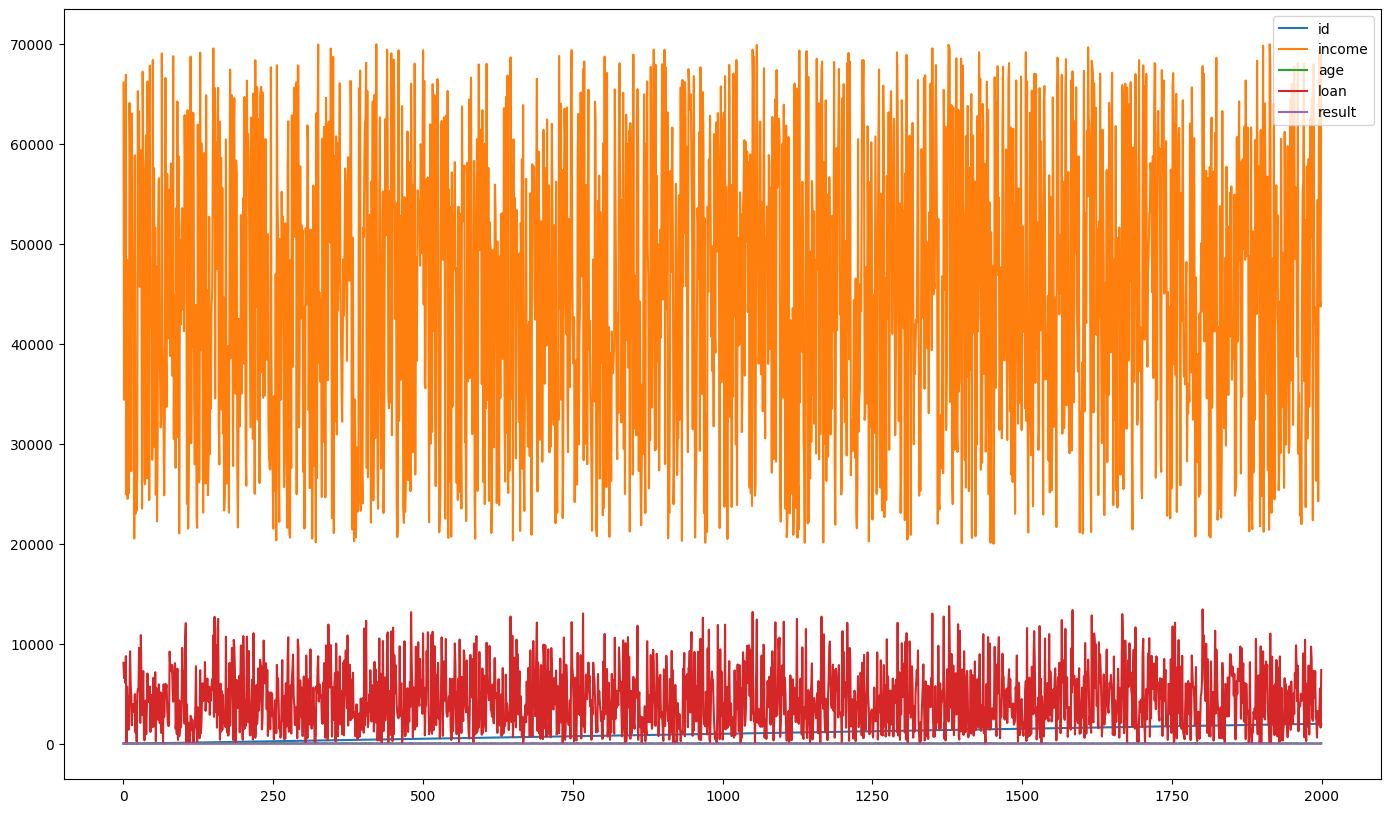

In [17]:
#Example of Graphics
#Dataframe Plot
df.plot(figsize=(17, 10))

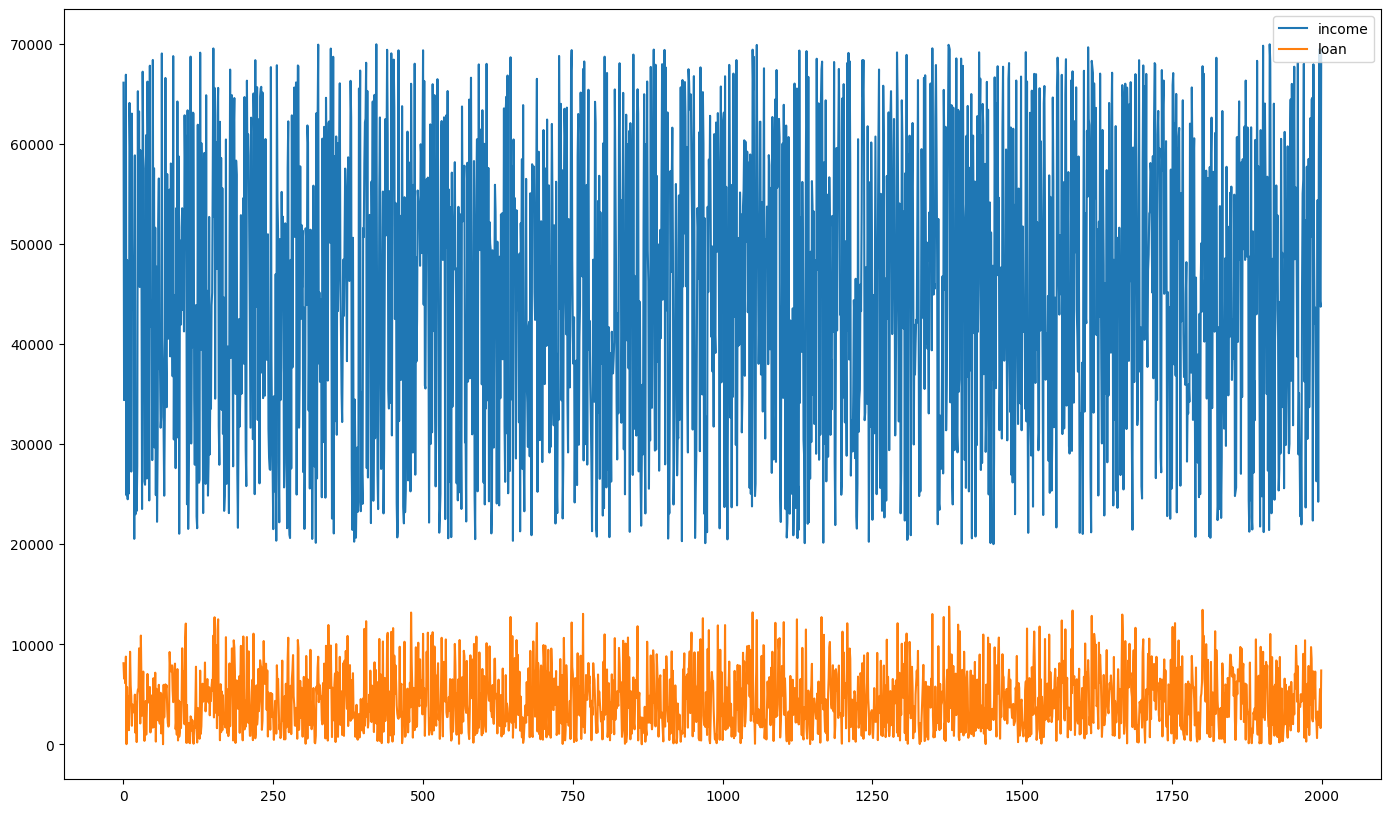

In [18]:
#Dataframe (Income and Loan Only) Plot
df[['income', 'loan']].plot(figsize=(17, 10));

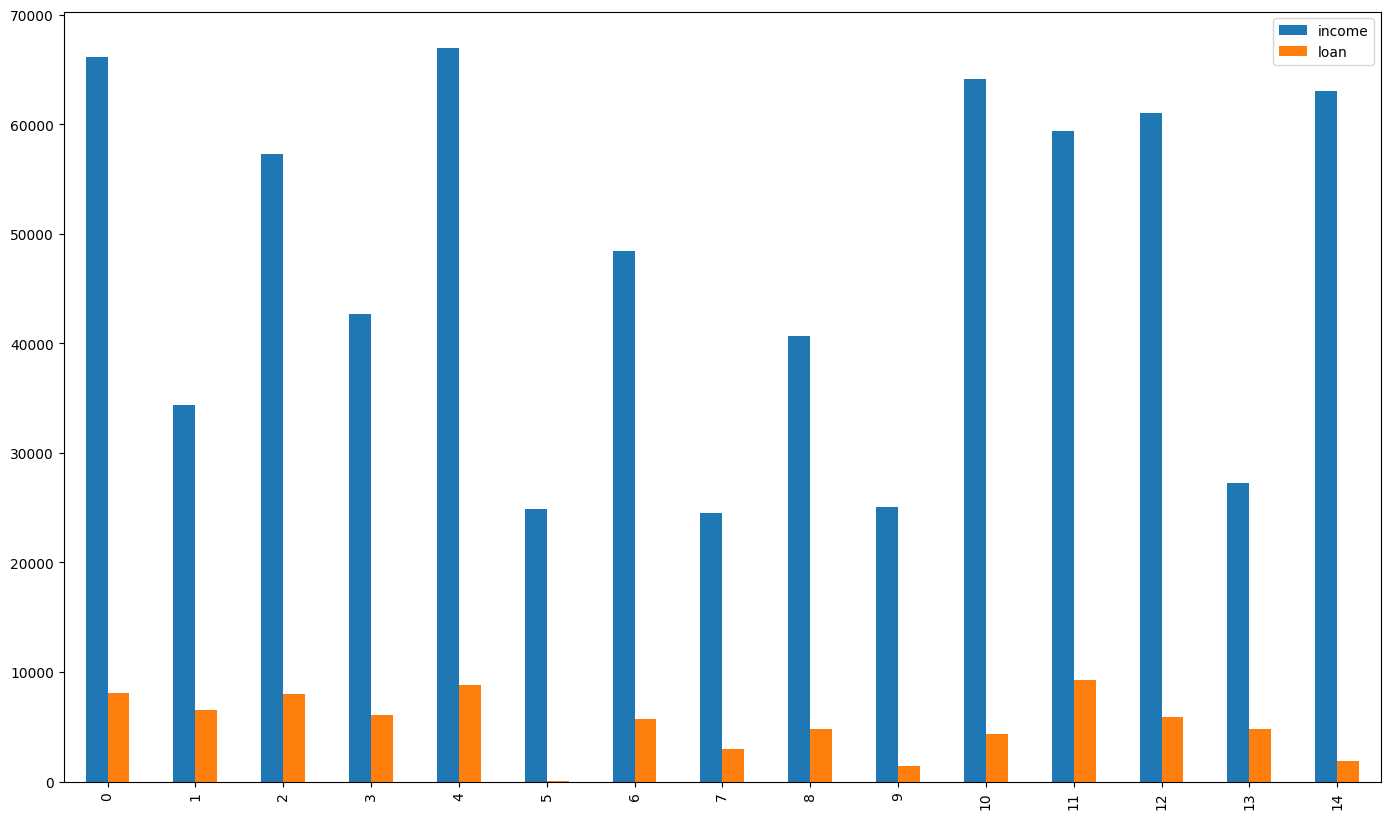

In [19]:
#Dataframe (Income and Loan with Bars) Plot
df[['income', 'loan']].head(15).plot.bar(figsize=(17, 10));

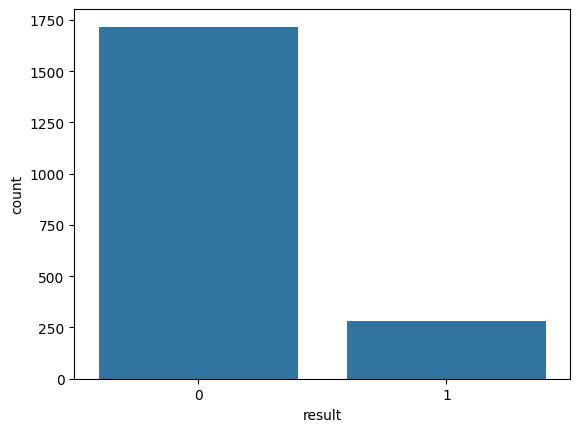

In [20]:
#Total of Values of Result
sns.countplot(x = df['result']);

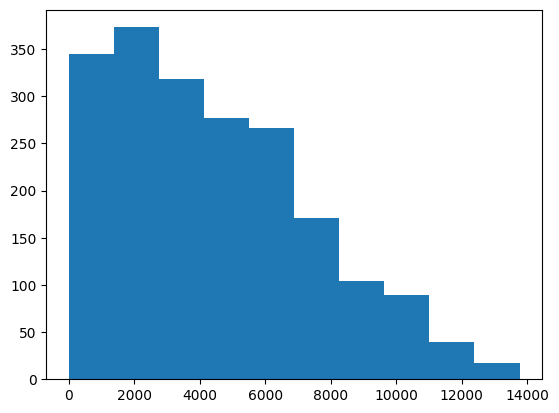

In [21]:
#Example of Histogram
plt.hist(x = df['loan']);

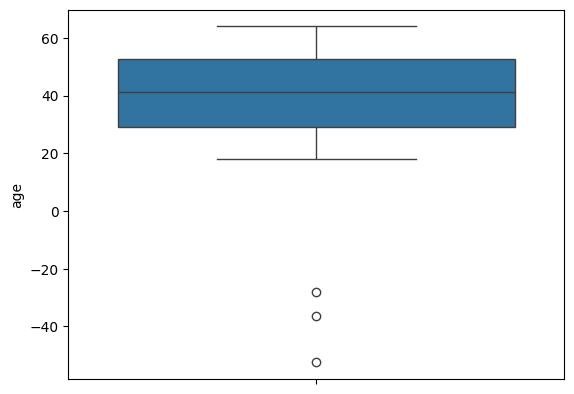

In [22]:
#Show the Attribute Distribution
sns.boxplot(df.age);

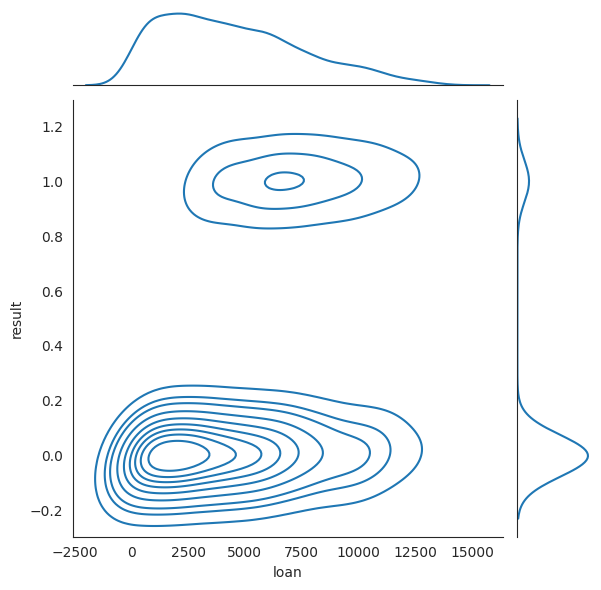

In [23]:
#Other Example of Attribute Distribution
with sns.axes_style('white'):
    sns.jointplot(x = df['loan'], y = df['result'], kind='kde');

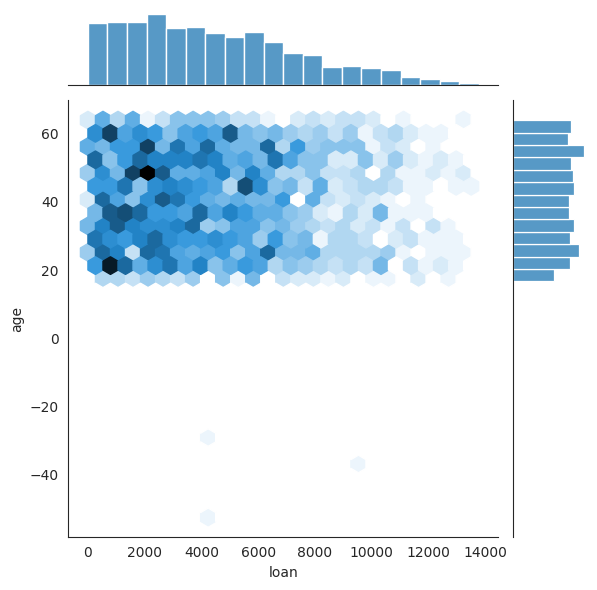

In [24]:
#Other Example of Attribute Distribution
with sns.axes_style('white'):
    sns.jointplot(x = df['loan'], y = df['age'], kind='hex');

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1832: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  func(x=self.x, y=self.y, **kwargs)


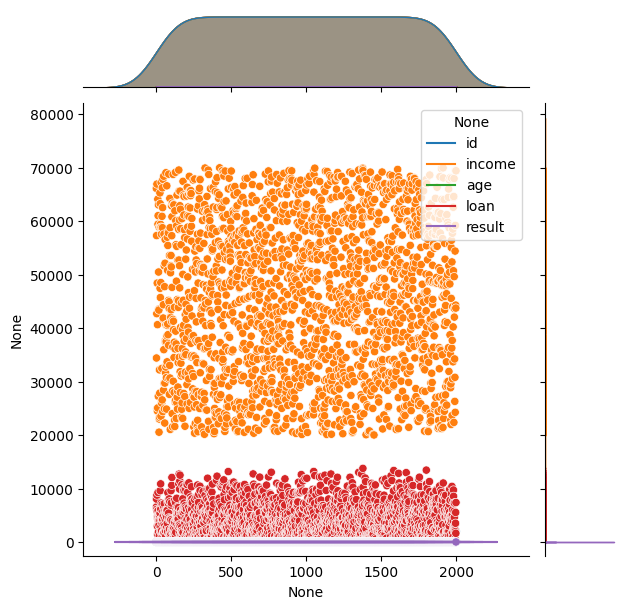

In [25]:
#Other Example of Attribute Distribution
sns.jointplot(data = df).plot_joint(sns.kdeplot).plot_marginals(sns.rugplot);

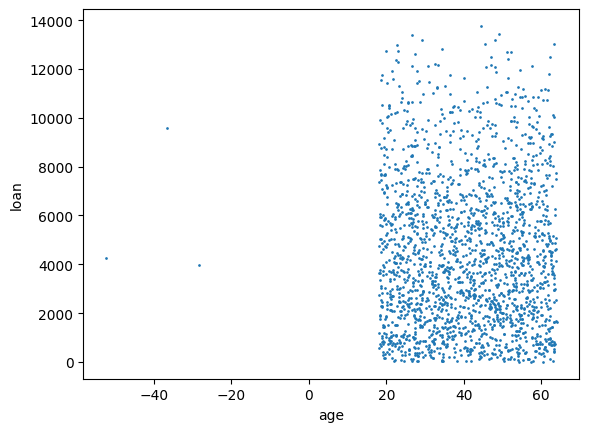

In [26]:
#Other Example of Attribute Distribution
df.plot(kind='scatter', x='age', y='loan', s=0.9);

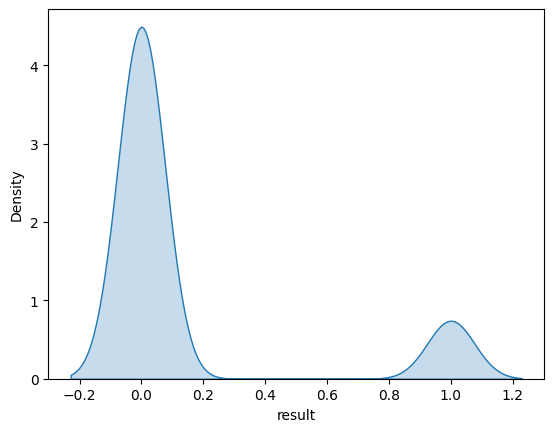

In [27]:
#Other Example of Attribute Distribution
sns.kdeplot(x = df['result'], shade=True);

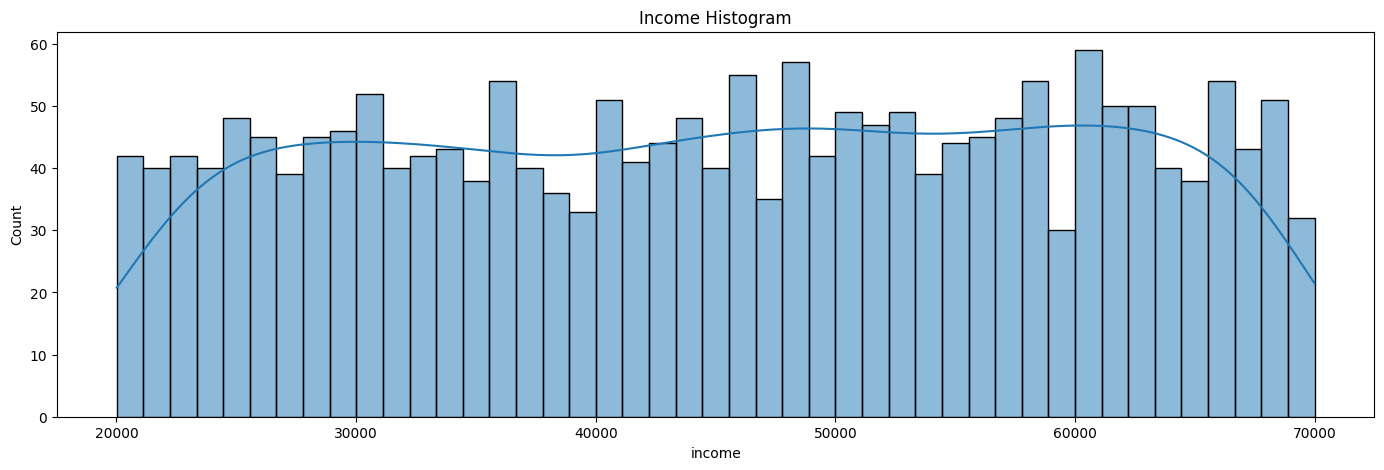

In [28]:
#Full Histogram
plt.figure(figsize=(17,5));
sns.histplot(df["income"], kde=True, bins=45)
plt.title("Income Histogram");

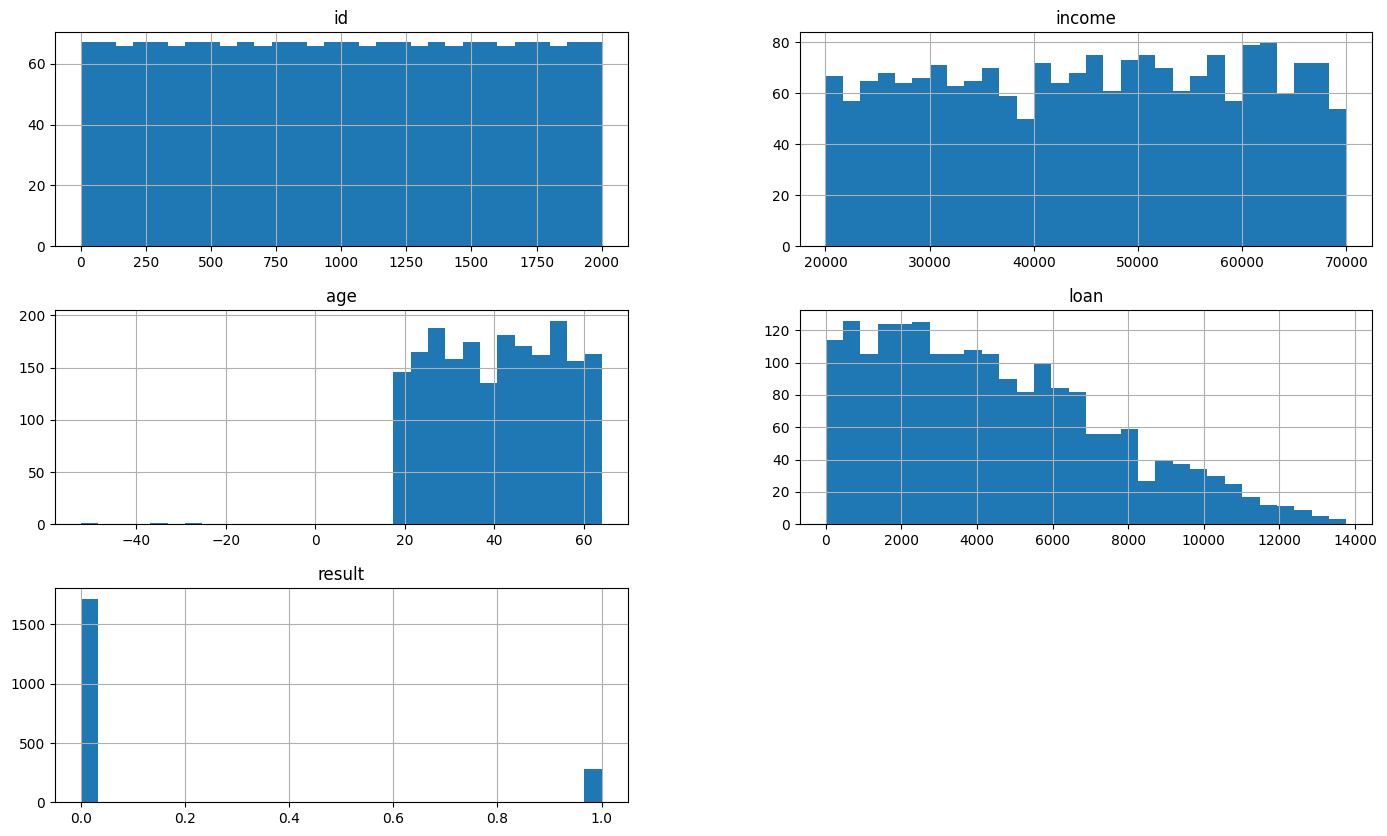

In [29]:
# All Histograms múltiplos para colunas numéricas
df.hist(bins=30, figsize=(17, 10))
plt.show()

<Axes: xlabel='age', ylabel='Count'>

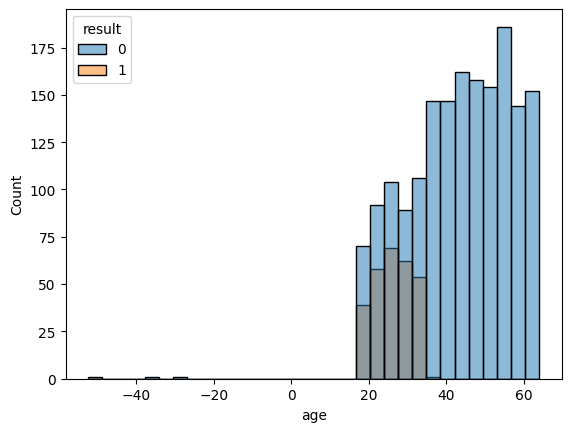

In [30]:
#Other Example of Full Histogram
sns.histplot(data=df, x="age", hue="result")

In [31]:
#Show the Graphics
graph = px.scatter_matrix(df, dimensions=['age', 'income', 'loan'], color = 'result')

In [32]:
graph.show()

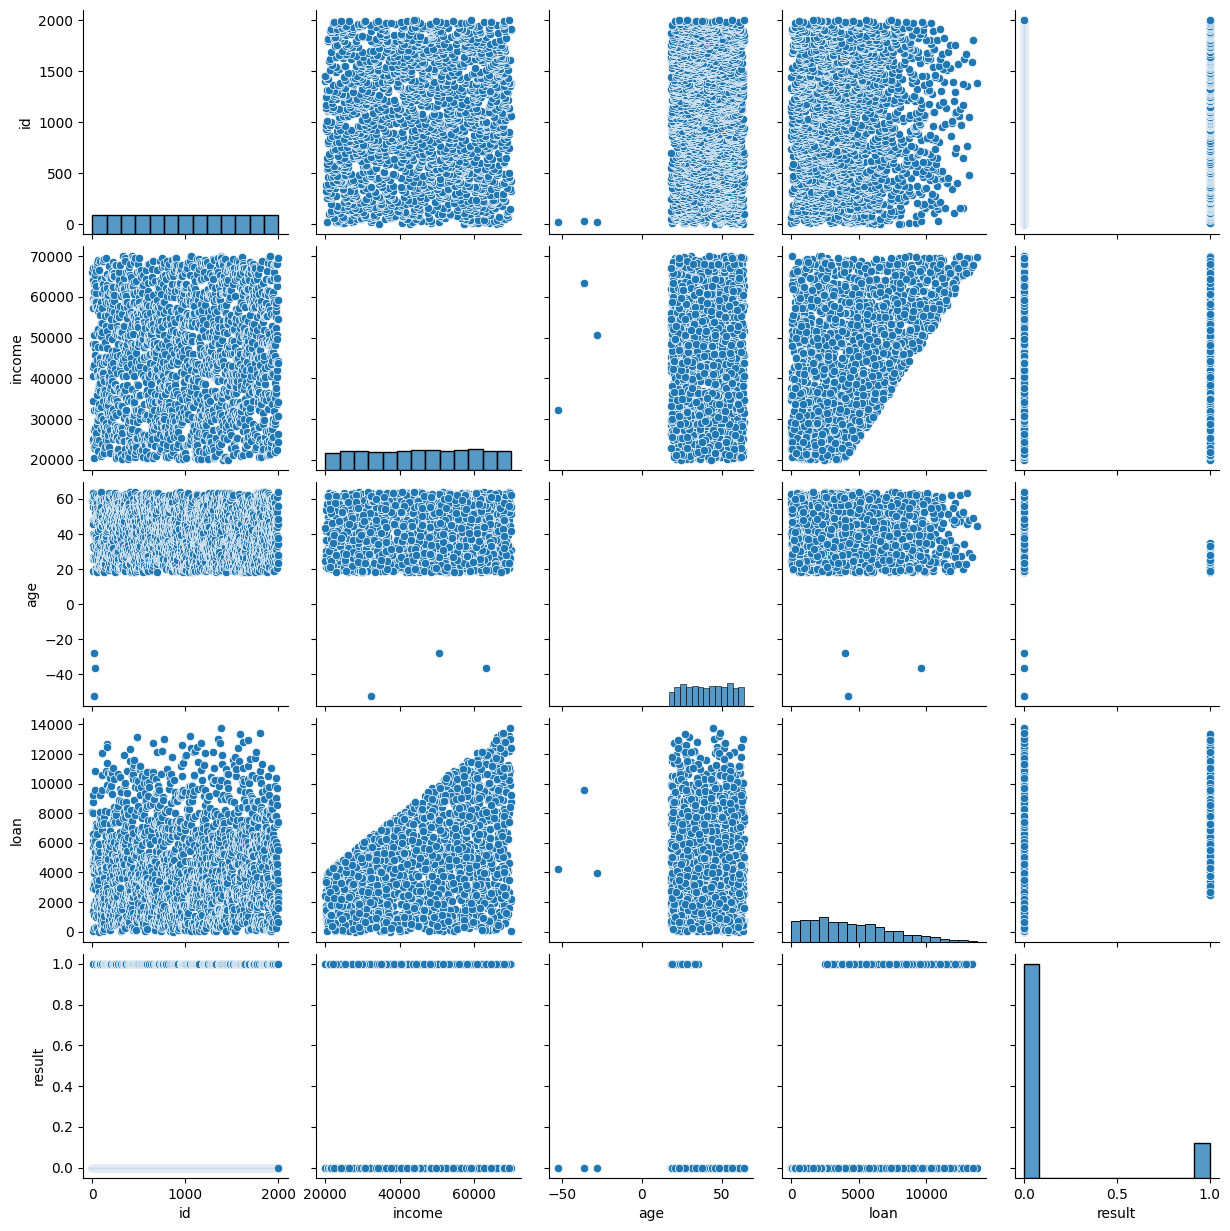

In [33]:
#Full Fair Plot
sns.pairplot(df);